In [1]:
import numpy as np
import pandas as pd
import mediapipe as mp
import cv2
from tensorflow.keras.utils import to_categorical

# Load data
train_df = pd.read_csv('C:/Users/Ranuga/Downloads/archive (3)/sign_mnist_train/sign_mnist_train.csv')
x_train = train_df.drop('label', axis=1).values.reshape(-1, 28, 28)
y_train = train_df['label'].values

# Initialize MediaPipe
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5)

def extract_landmarks(images):
    data = []
    labels = []
    print("Extracting landmarks (this may take a few minutes)...")
    
    for i, img in enumerate(images):
        # 1. Ensure image is in 0-255 uint8 format
        img_uint8 = (img * 255).astype('uint8') if img.max() <= 1.0 else img.astype('uint8')
        
        # 2. Convert to RGB (MediaPipe requirement)
        img_rgb = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2RGB)
        
        # 3. Process the image
        results = hands.process(img_rgb)
        
        # 4. If landmarks are found, save them
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                lm_list = []
                for lm in hand_landmarks.landmark:
                    lm_list.extend([lm.x, lm.y, lm.z])
                
                data.append(lm_list)
                labels.append(y_train[i])
        
        # Progress update every 1000 images
        if i % 1000 == 0:
            print(f"Processed {i}/{len(images)} images...")
            
    return np.array(data), np.array(labels)

x_landmarks, y_labels = extract_landmarks(x_train)
y_cat = to_categorical(y_labels, num_classes=26)

print(f"Extraction complete! Found hands in {len(x_landmarks)} images.")

Extracting landmarks (this may take a few minutes)...
Processed 0/27455 images...
Processed 1000/27455 images...
Processed 2000/27455 images...
Processed 3000/27455 images...
Processed 4000/27455 images...
Processed 5000/27455 images...
Processed 6000/27455 images...
Processed 7000/27455 images...
Processed 8000/27455 images...
Processed 9000/27455 images...
Processed 10000/27455 images...
Processed 11000/27455 images...
Processed 12000/27455 images...
Processed 13000/27455 images...
Processed 14000/27455 images...
Processed 15000/27455 images...
Processed 16000/27455 images...
Processed 17000/27455 images...
Processed 18000/27455 images...
Processed 19000/27455 images...
Processed 20000/27455 images...
Processed 21000/27455 images...
Processed 22000/27455 images...
Processed 23000/27455 images...
Processed 24000/27455 images...
Processed 25000/27455 images...
Processed 26000/27455 images...
Processed 27000/27455 images...
Extraction complete! Found hands in 334 images.


In [3]:
def extract_geometric_features(landmarks_array):
    """
    Transforms 63 raw coordinates into 20 distance-based features 
    calculated from the wrist (Point 0).
    """
    geometric_data = []
    
    for lm_list in landmarks_array:
        # Reshape the 63 values back to (21 points, 3 coordinates)
        coords = np.array(lm_list).reshape(21, 3)
        wrist = coords[0] 
        
        # Calculate Euclidean distance from wrist to all other 20 points
        features = []
        for i in range(1, 21):
            # Distance formula: sqrt((x2-x1)^2 + (y2-y1)^2 + (z2-z1)^2)
            dist = np.linalg.norm(coords[i] - wrist)
            features.append(dist)
            
        geometric_data.append(features)
        
    return np.array(geometric_data)

# Transform your extracted landmarks
x_geometric = extract_geometric_features(x_landmarks)

print(f"Geometric Features Shape: {x_geometric.shape}") 
# Should be (Number of samples, 20)

Geometric Features Shape: (334, 20)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

# 4. BUILD THE GEOMETRIC ANN
model_geo = Sequential([
    # Input is 20 (The distance from wrist to each joint)
    Dense(128, activation='relu', input_shape=(20,)),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(26, activation='softmax') # 26 classes for A-Z
])

model_geo.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 5. TRAIN
print("Training the Geometric Model...")
history = model_geo.fit(
    x_geometric, y_cat, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.2,
    verbose=1
)

# 6. SAVE
model_geo.save('sign_mnist_geometric.keras')
print("Model saved as sign_mnist_geometric.keras")

Training the Geometric Model...
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.0732 - loss: 3.6176 - val_accuracy: 0.1194 - val_loss: 3.1390
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2946 - loss: 2.6082 - val_accuracy: 0.1194 - val_loss: 3.0946
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4336 - loss: 2.2294 - val_accuracy: 0.1194 - val_loss: 3.0592
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4763 - loss: 2.0568 - val_accuracy: 0.1493 - val_loss: 3.0318
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4810 - loss: 2.0050 - val_accuracy: 0.1940 - val_loss: 3.0062
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4976 - loss: 1.8915 - val_accuracy: 0.2537 - val_loss: 2.9966
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5148 - loss: 1.7780 - val_accuracy: 0.2836 - val_loss: 2.9775
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.6049 - loss: 1.5886 - val_accu

In [6]:

# Load Test Data
test_df = pd.read_csv('C:/Users/Ranuga/Downloads/archive (3)/sign_mnist_test/sign_mnist_test.csv')
x_test_imgs = test_df.drop('label', axis=1).values.reshape(-1, 28, 28)
y_test_labels = test_df['label'].values

# 1. Extract Raw Landmarks from Test Images
print("Extracting landmarks from test set...")
x_test_landmarks, y_test_filtered = extract_landmarks(x_test_imgs)

# 2. Convert Raw Landmarks to 20 Geometric Features
x_test_geo = extract_geometric_features(x_test_landmarks)
y_cat_test_geo = to_categorical(y_test_filtered, num_classes=26)

Extracting landmarks from test set...
Extracting landmarks (this may take a few minutes)...
Processed 0/7172 images...
Processed 1000/7172 images...
Processed 2000/7172 images...
Processed 3000/7172 images...
Processed 4000/7172 images...
Processed 5000/7172 images...
Processed 6000/7172 images...
Processed 7000/7172 images...


In [7]:
from tensorflow.keras.models import load_model

# ===============================
# 6. LOAD & EVALUATE MODEL
# ===============================
# Load the model from your local directory
model_geo = load_model('sign_mnist_geometric.keras')
print("Model 'sign_mnist_geometric.keras' loaded successfully.")

# Now evaluate using the loaded model
test_loss, test_acc = model_geo.evaluate(x_test_geo, y_cat_test_geo)
print(f"\nTest Accuracy (Geometric): {test_acc:.4f}")


Model 'sign_mnist_geometric.keras' loaded successfully.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0302 - loss: 3.7070     

Test Accuracy (Geometric): 0.0312


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         5
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         8
           4       0.03      0.20      0.06         5
           5       0.00      0.00      0.00         4
           6       0.00      0.00      0.00         5
           7       0.00      0.00      0.00         7
           8       0.00      0.00      0.00         6
          10       0.00      0.00      0.00         5
          11       0.00      0.00      0.00         7
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00         7
          15       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         6
          17      

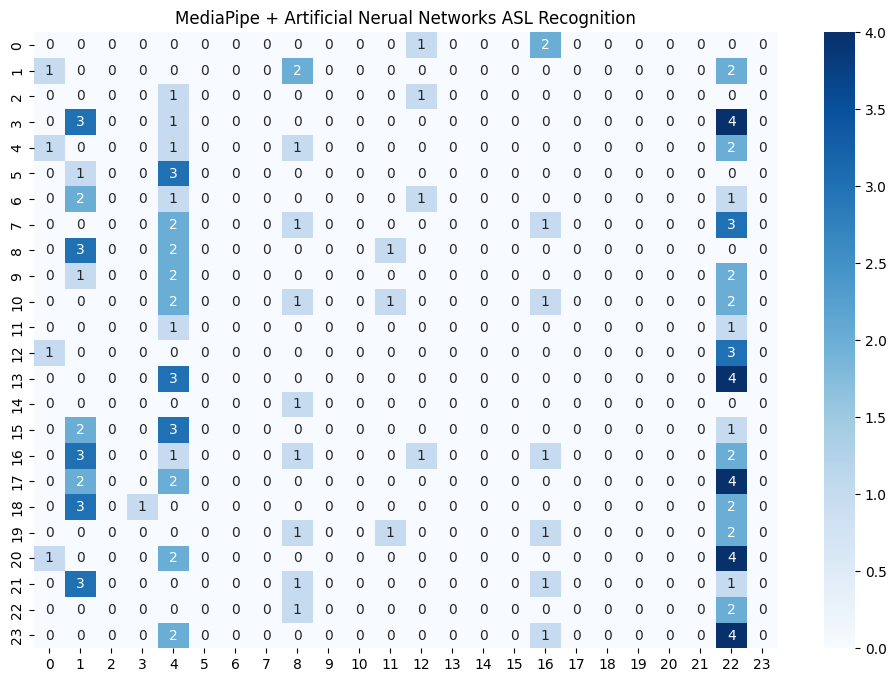

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Get Predictions (Section 7)
y_pred_prob = model_geo.predict(x_test_geo)
y_pred = np.argmax(y_pred_prob, axis=1)

# 3. Metrics (Section 8)
from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report:")
print(classification_report(y_test_filtered, y_pred, zero_division=0))

# 4. Visual Confusion Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_matrix(y_test_filtered, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("MediaPipe + Artificial Nerual Networks ASL Recognition")
plt.show()

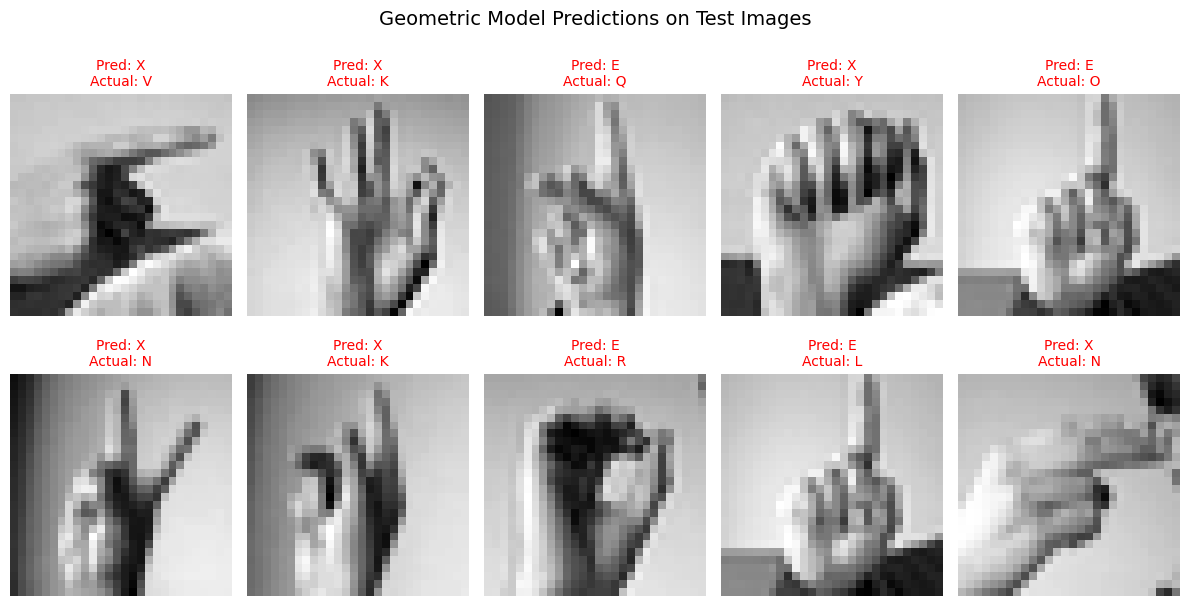

In [11]:
# ===============================
# 9. VISUALIZE SAMPLE PREDICTIONS
# ===============================
plt.figure(figsize=(12, 6))
alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

# We use the first 10 successful detections
for i in range(10):
    plt.subplot(2, 5, i+1)
    
    # To show the image, we need to find its original index 
    # But for simplicity, we can just show the processed ones
    # We find where MediaPipe successfully found a hand in the original x_test_imgs
    plt.imshow(x_test_imgs[i].reshape(28, 28), cmap='gray')
    
    pred_letter = alphabet[y_pred[i]]
    actual_letter = alphabet[y_test_filtered[i]]
    
    title_color = 'green' if y_pred[i] == y_test_filtered[i] else 'red'
    
    plt.title(f"Pred: {pred_letter}\nActual: {actual_letter}", color=title_color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.suptitle("MediaPipe + ANN Using 28x28 Pixel Dataset", y=1.05, fontsize=14)
plt.show()

In [12]:
import cv2
import mediapipe as mp
import numpy as np
from tensorflow.keras.models import load_model

# 1. Load the Geometric Model
# Ensure this file is in the same folder as this script
model = load_model('sign_mnist_geometric.keras')

# 2. Setup MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=False, 
    max_num_hands=1, 
    min_detection_confidence=0.7, 
    min_tracking_confidence=0.5
)
mp_draw = mp.solutions.drawing_utils

# 3. Alphabet Mapping (Skips J and Z as per Sign MNIST)
alphabet = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 
            'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']

def get_geometric_features(hand_landmarks):
    """
    Extracts the 20 distances from the wrist to each joint.
    This matches the training logic.
    """
    coords = []
    for lm in hand_landmarks.landmark:
        coords.append([lm.x, lm.y, lm.z])
    
    coords = np.array(coords)
    wrist = coords[0]
    
    features = []
    for i in range(1, 21):
        dist = np.linalg.norm(coords[i] - wrist)
        features.append(dist)
    
    return np.array(features).reshape(1, 20)

# 4. Start Webcam
cap = cv2.VideoCapture(0)

print("Starting Geometric Tracking... Press 'q' to quit.")

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # Flip and convert to RGB
    frame = cv2.flip(frame, 1)
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Process with MediaPipe
    results = hands.process(img_rgb)
    
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            # Draw the skeleton (The "Proof" that we only use geometry)
            mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)
            
            # Extract Geometric Features
            geo_features = get_geometric_features(hand_landmarks)
            
            # Predict
            prediction = model.predict(geo_features, verbose=0)
            class_id = np.argmax(prediction)
            confidence = np.max(prediction)
            
            # Display Results
            if confidence > 0.6: # Confidence threshold
                char = alphabet[class_id] if class_id < len(alphabet) else "?"
                display_text = f"Geometric Pred: {char} ({confidence*100:.1f}%)"
                color = (0, 255, 0)
            else:
                display_text = "Analyzing..."
                color = (0, 255, 255)
                
            cv2.putText(frame, display_text, (50, 50), 
                        cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

    cv2.imshow('MediaPipe Geometric Mode', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Starting Geometric Tracking... Press 'q' to quit.
